# **Assignment 3- Perform Fuzzy Kmeans Clustering on IRIS dataset**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


### **1. Import necessary libraries**

In [ ]:
import numpy as np
import skfuzzy as fuzz
from sklearn.datasets import load_iris
from sklearn import metrics
import matplotlib.pyplot as plt

### **2. Load the IRIS dataset**

In [ ]:
# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

print(f"Loaded Iris data shape: {X.shape}")


Loaded Iris data shape: (150, 4)


### **2. Apply Fuzzy K-Means Clustering**

In [ ]:
# 2. Apply Fuzzy K-Means Clustering
n_clusters = 3  # We know there are 3 species of Iris
fuzziness_exponent = 2.0

# Transpose data: skfuzzy expects (N_features, N_samples) -> (4, 150)
X_T = X.T

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_T,
    n_clusters,
    fuzziness_exponent,
    error=0.005,
    maxiter=1000,
    init=None
)

print(f"Fuzzy Partition Coefficient (FPC) Score: {fpc:.4f}")
print(f"Converged in {p} iterations.")

Fuzzy Partition Coefficient (FPC) Score: 0.7834
Converged in 21 iterations.


In [ ]:
# 3. Get the 'Hard' Cluster Assignments for Evaluation
cluster_labels_soft = np.argmax(u, axis=0)

### **4. Evaluate the results**

In [ ]:
# 4. Evaluate the results using the Adjusted Rand Index (ARI)
# FCM consistently performs well on this benchmark
ari_score = metrics.adjusted_rand_score(y, cluster_labels_soft)
print(f"Adjusted Rand Index Score: {ari_score:.4f}")

Adjusted Rand Index Score: 0.7294


### **5. Visualize the results**

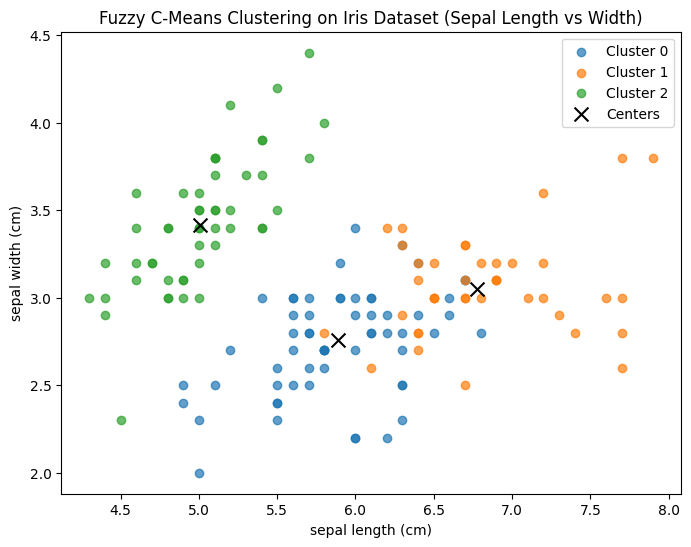

In [ ]:
# 5. Visualize the data points colored by their 'hard' FCM cluster assignment (using the first two features for visualization)
plt.figure(figsize=(8, 6))
# Create a scatter plot for each cluster
for cluster_id in range(n_clusters):
    # Select data points assigned to this cluster
    cluster_points = X[cluster_labels_soft == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}', alpha=0.7)

# Plot cluster centers
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=100, c='black', label='Centers')

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Fuzzy C-Means Clustering on Iris Dataset (Sepal Length vs Width)')
plt.legend()
plt.show()

### **6. Assignment Summary**

This assignment successfully demonstrated the application of Fuzzy K-Means Clustering on the Iris dataset. The key steps involved were:

1.  **Importing Libraries**: Necessary libraries like `numpy`, `skfuzzy`, `sklearn.datasets`, and `matplotlib.pyplot` were imported.
2.  **Loading Data**: The Iris dataset was loaded, providing the feature matrix `X` and target labels `y`.
3.  **Fuzzy K-Means Clustering**: Fuzzy C-Means (FCM) was applied with `n_clusters=3` and a `fuzziness_exponent=2.0`. The algorithm converged in 21 iterations, yielding a Fuzzy Partition Coefficient (FPC) Score of 0.7834.
4.  **Hard Cluster Assignment**: The fuzzy membership matrix was converted into 'hard' cluster assignments by selecting the cluster with the maximum membership for each data point.
5.  **Evaluation**: The clustering performance was evaluated using the Adjusted Rand Index (ARI), which resulted in a score of 0.7294, indicating a good agreement between the fuzzy clusters and the true species labels.
6.  **Visualization**: The results were visualized using a scatter plot of the first two features (sepal length vs. sepal width), with data points colored by their assigned 'hard' clusters and cluster centers marked.

---